['.ipynb_checkpoints',
 'Lab.7.ipynb',
 'Lab.7.pdf',
 'lab7solution.ipynb',
 'Untitled.ipynb']

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:
test_df = pd.read_csv(
    "supersymmetry_dataset.csv",
    header=None,
    nrows=1000
)

test_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,SUSY,lepton 1 pT,lepton 1 eta,lepton 1 phi,lepton 2 pT,lepton 2 eta,lepton 2 phi,missing energy magnitude,missing energy phi,MET_rel,axial MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos(theta_r1)
1,0.0,0.7072581052780151,0.6131593585014344,-0.7633536458015443,1.0108135938644407,1.67210066318512,1.5443141460418701,0.3426413238048553,0.2869439423084259,0.5143468976020813,-0.007999504916369915,0.8328003883361816,0.6462172269821167,0.6885806918144225,1.159058690071106,0.8074854016304015,0.890079915523529,0.2727180123329162,0.014630899764597416
2,0.0,0.4937452077865601,-1.7455810308456419,-0.640967607498169,0.5761610269546508,-0.5144768357276917,-0.6297879219055176,0.5858405232429504,0.8740382790565491,0.8794188499450682,-0.2217007875442505,0.5539438128471376,0.7704219222068786,1.234179854393005,1.6711711883544922,0.5115889310836792,1.2555313110351562,0.5215924978256224,0.1582220047712326
3,1.0,1.3054134845733645,0.2838199734687805,-1.1491543054580688,0.5072165131568908,-0.19416143000125885,1.3139927387237549,0.6598323583602904,0.6195926666259766,0.5349217653274536,-0.3202984035015107,0.8619707822799682,1.0856021642684937,1.117619514465332,1.1999409198760986,0.7547780275344848,0.9844586849212646,0.2358917742967605,0.6016309857368468
4,1.0,0.8097153306007386,-0.3583029806613922,-0.4971718788146973,0.7876746654510497,0.02741886489093304,1.201305270195007,0.7905557751655578,-0.8619232773780823,0.7402867078781128,0.8905254006385804,0.6847708225250244,0.7176397442817688,0.9299892783164976,0.3412248194217682,0.6838286519050598,0.4927410483360291,1.2838294506072998,0.1158509999513626


In [12]:
VarNames = [
    "signal", "l_1_pT", "l_1_eta", "l_1_phi",
    "l_2_pT", "l_2_eta", "l_2_phi",
    "MET", "MET_phi", "MET_rel", "axial_MET",
    "M_R", "M_TR_2", "R", "MT2", "S_R",
    "M_Delta_R", "dPhi_r_b", "cos_theta_r1"
]

df = pd.read_csv(
    "supersymmetry_dataset.csv",
    skiprows=1,
    names=VarNames,
    nrows=50000,
    dtype='float64'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   signal        50000 non-null  float64
 1   l_1_pT        50000 non-null  float64
 2   l_1_eta       50000 non-null  float64
 3   l_1_phi       50000 non-null  float64
 4   l_2_pT        50000 non-null  float64
 5   l_2_eta       50000 non-null  float64
 6   l_2_phi       50000 non-null  float64
 7   MET           50000 non-null  float64
 8   MET_phi       50000 non-null  float64
 9   MET_rel       50000 non-null  float64
 10  axial_MET     50000 non-null  float64
 11  M_R           50000 non-null  float64
 12  M_TR_2        50000 non-null  float64
 13  R             50000 non-null  float64
 14  MT2           50000 non-null  float64
 15  S_R           50000 non-null  float64
 16  M_Delta_R     50000 non-null  float64
 17  dPhi_r_b      50000 non-null  float64
 18  cos_theta_r1  50000 non-nu

In [13]:
df.head()

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.707258,0.613159,-0.763354,1.010814,1.672101,1.544314,0.342641,0.286944,0.514347,-0.008000,0.832800,0.646217,0.688581,1.159059,0.807485,0.890080,0.272718,0.014631
1,0.0,0.493745,-1.745581,-0.640968,0.576161,-0.514477,-0.629788,0.585841,0.874038,0.879419,-0.221701,0.553944,0.770422,1.234180,1.671171,0.511589,1.255531,0.521592,0.158222
2,1.0,1.305413,0.283820,-1.149154,0.507217,-0.194161,1.313993,0.659832,0.619593,0.534922,-0.320298,0.861971,1.085602,1.117620,1.199941,0.754778,0.984459,0.235892,0.601631
3,1.0,0.809715,-0.358303,-0.497172,0.787675,0.027419,1.201305,0.790556,-0.861923,0.740287,0.890525,0.684771,0.717640,0.929989,0.341225,0.683829,0.492741,1.283829,0.115851
4,0.0,0.912852,1.797455,-1.360165,0.496723,1.199644,0.627462,1.206452,-1.362983,0.033791,1.509121,0.659545,0.652570,0.878010,0.000000,0.580894,0.143379,1.438492,0.230821


In [14]:
df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

print("Signal shape:", df_sig.shape)
print("Background shape:", df_bkg.shape)

Signal shape: (22738, 19)
Background shape: (27262, 19)


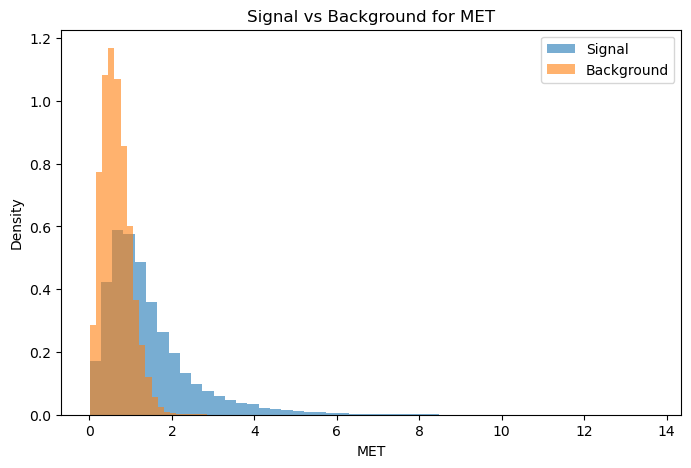

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df_sig['MET'], bins=50, alpha=0.6, density=True, label='Signal')
plt.hist(df_bkg['MET'], bins=50, alpha=0.6, density=True, label='Background')

plt.xlabel('MET')
plt.ylabel('Density')
plt.title('Signal vs Background for MET')
plt.legend()
plt.show()

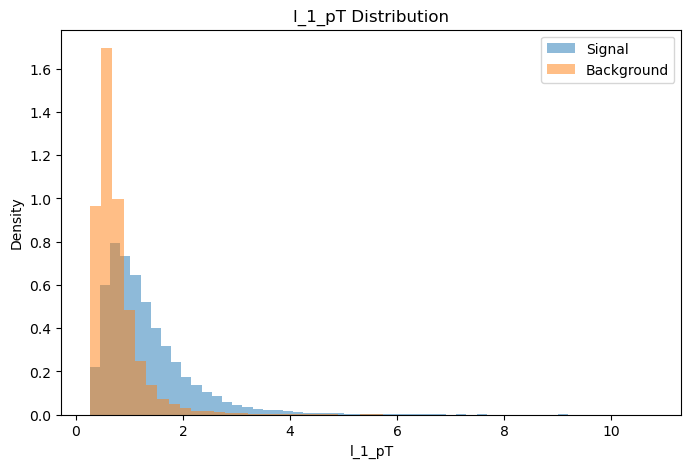

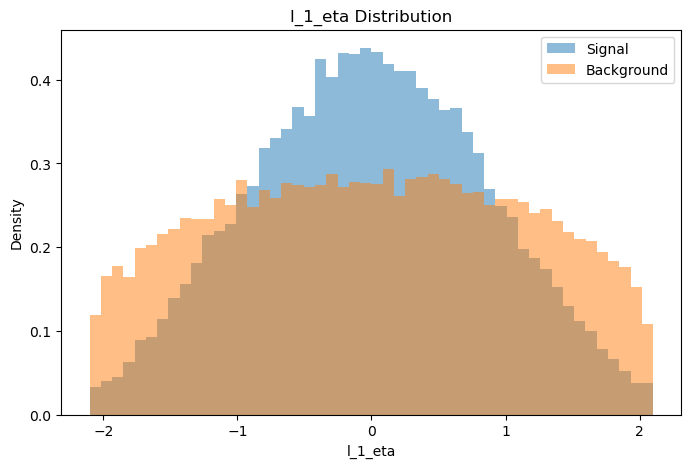

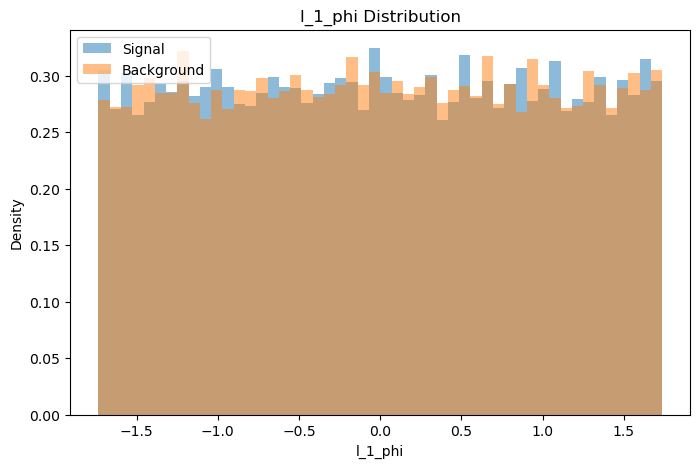

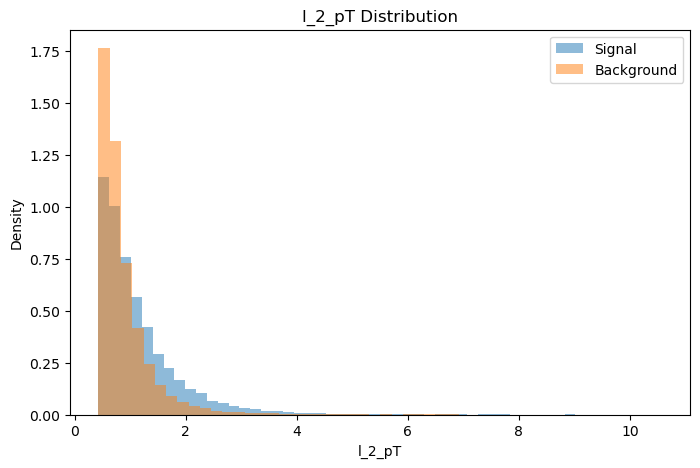

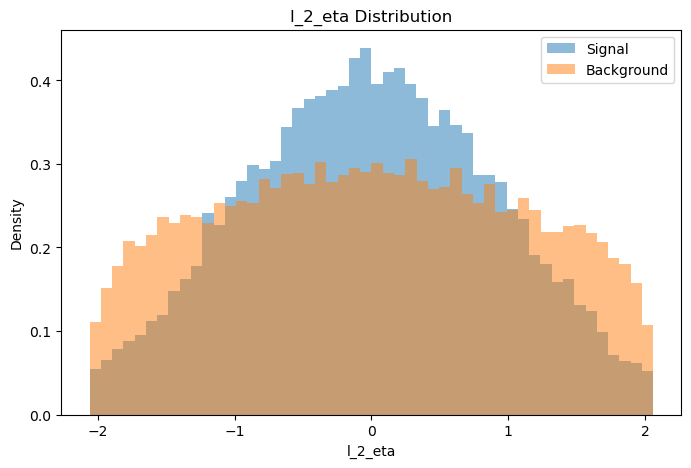

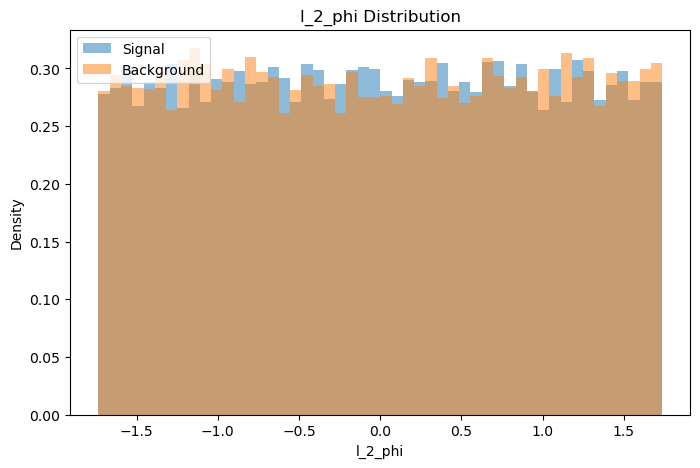

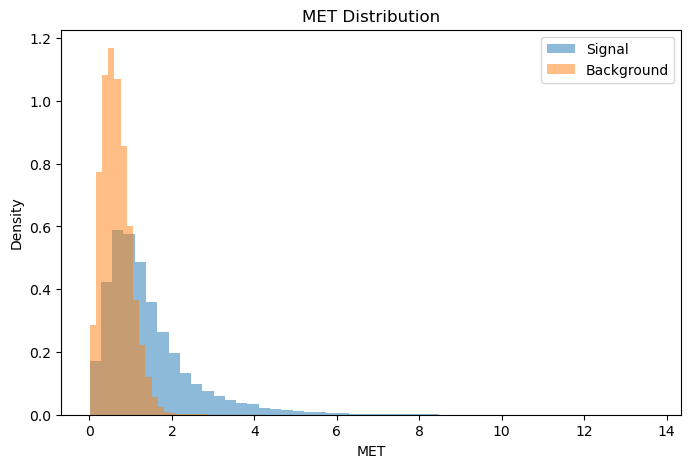

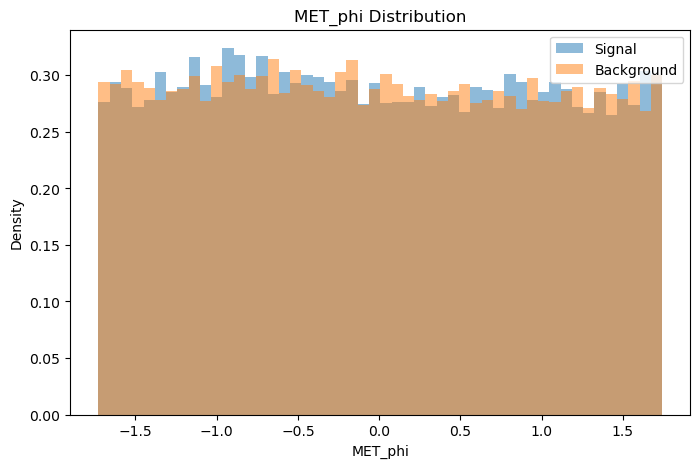

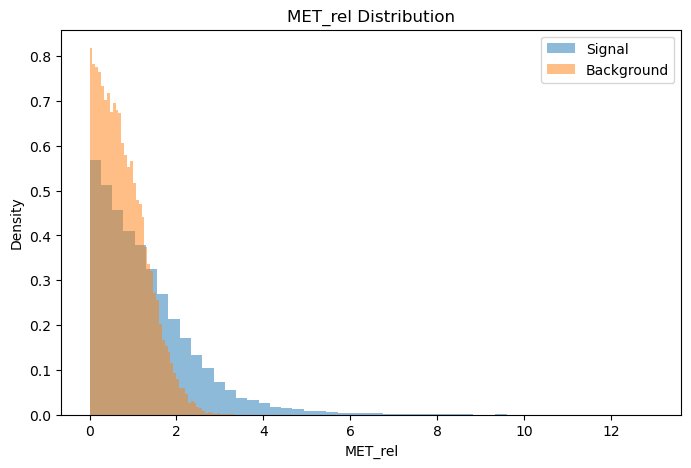

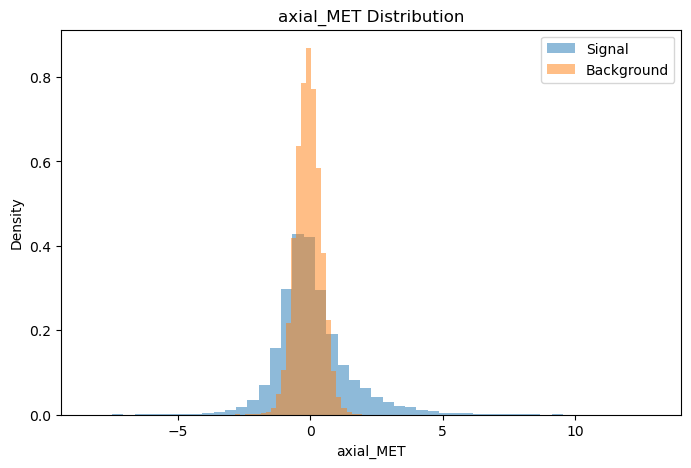

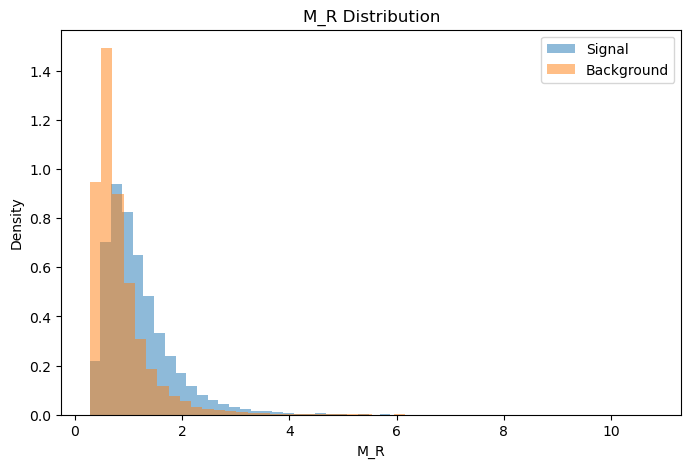

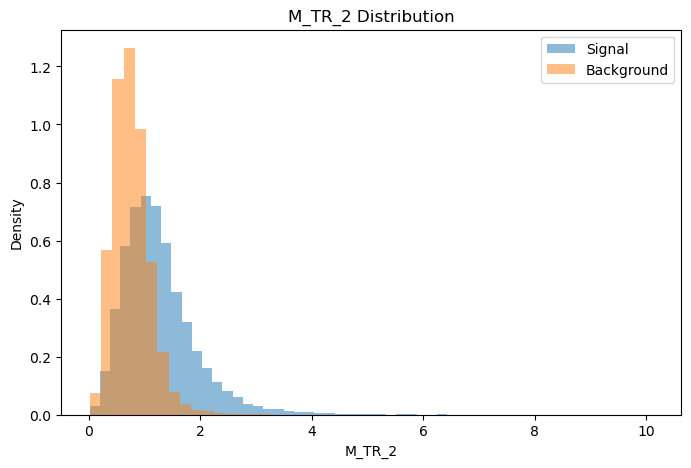

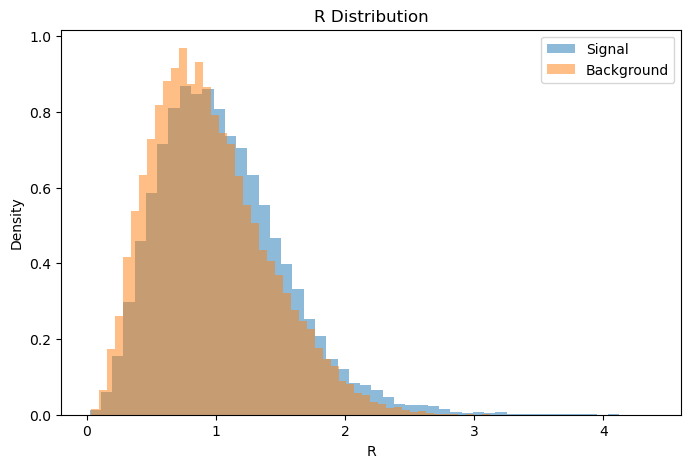

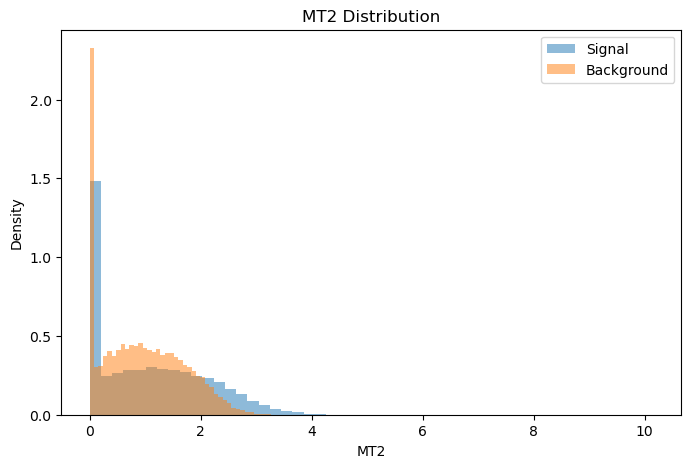

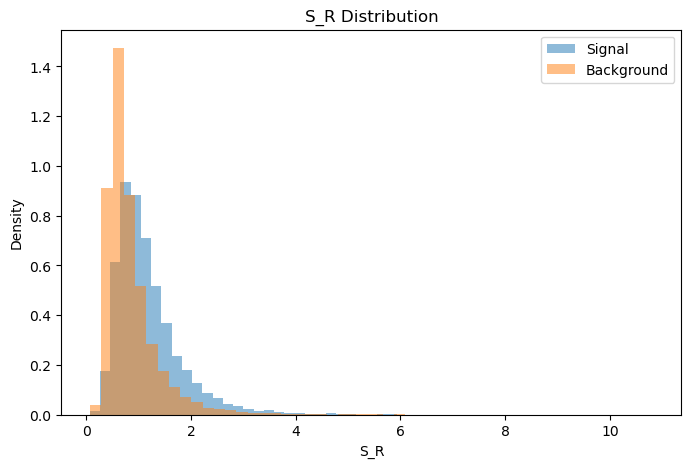

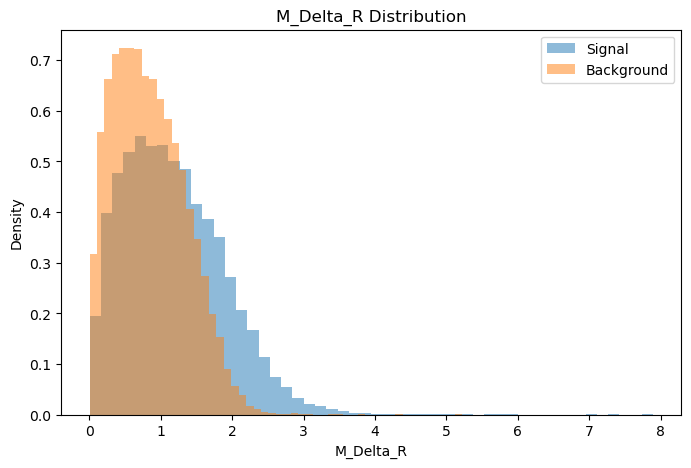

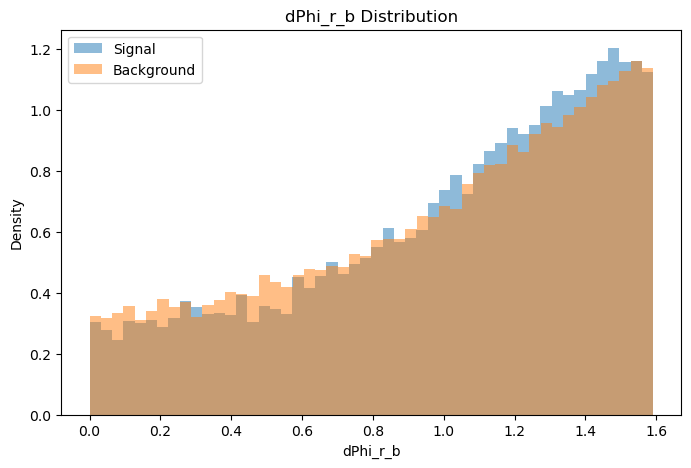

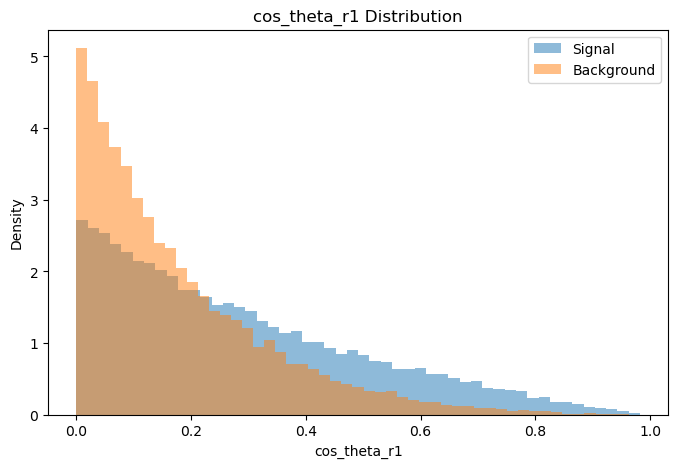

In [16]:
for var in VarNames[1:]:

    plt.figure(figsize=(8,5))

    plt.hist(df_sig[var], bins=50, alpha=0.5, density=True, label='Signal')
    plt.hist(df_bkg[var], bins=50, alpha=0.5, density=True, label='Background')

    plt.xlabel(var)
    plt.ylabel('Density')
    plt.title(f'{var} Distribution')

    plt.legend()
    plt.show()

In [17]:
def pair_plot(data, variables, sample_size=2000):

    sample = data[variables].sample(sample_size)

    n = len(variables)

    fig, axes = plt.subplots(n, n, figsize=(15,15))

    for i in range(n):
        for j in range(n):

            if i == j:
                axes[i,j].hist(sample[variables[i]], bins=30)

            else:
                axes[i,j].scatter(
                    sample[variables[j]],
                    sample[variables[i]],
                    s=1
                )

            if i == n-1:
                axes[i,j].set_xlabel(variables[j])

            if j == 0:
                axes[i,j].set_ylabel(variables[i])

    plt.tight_layout()
    plt.show()

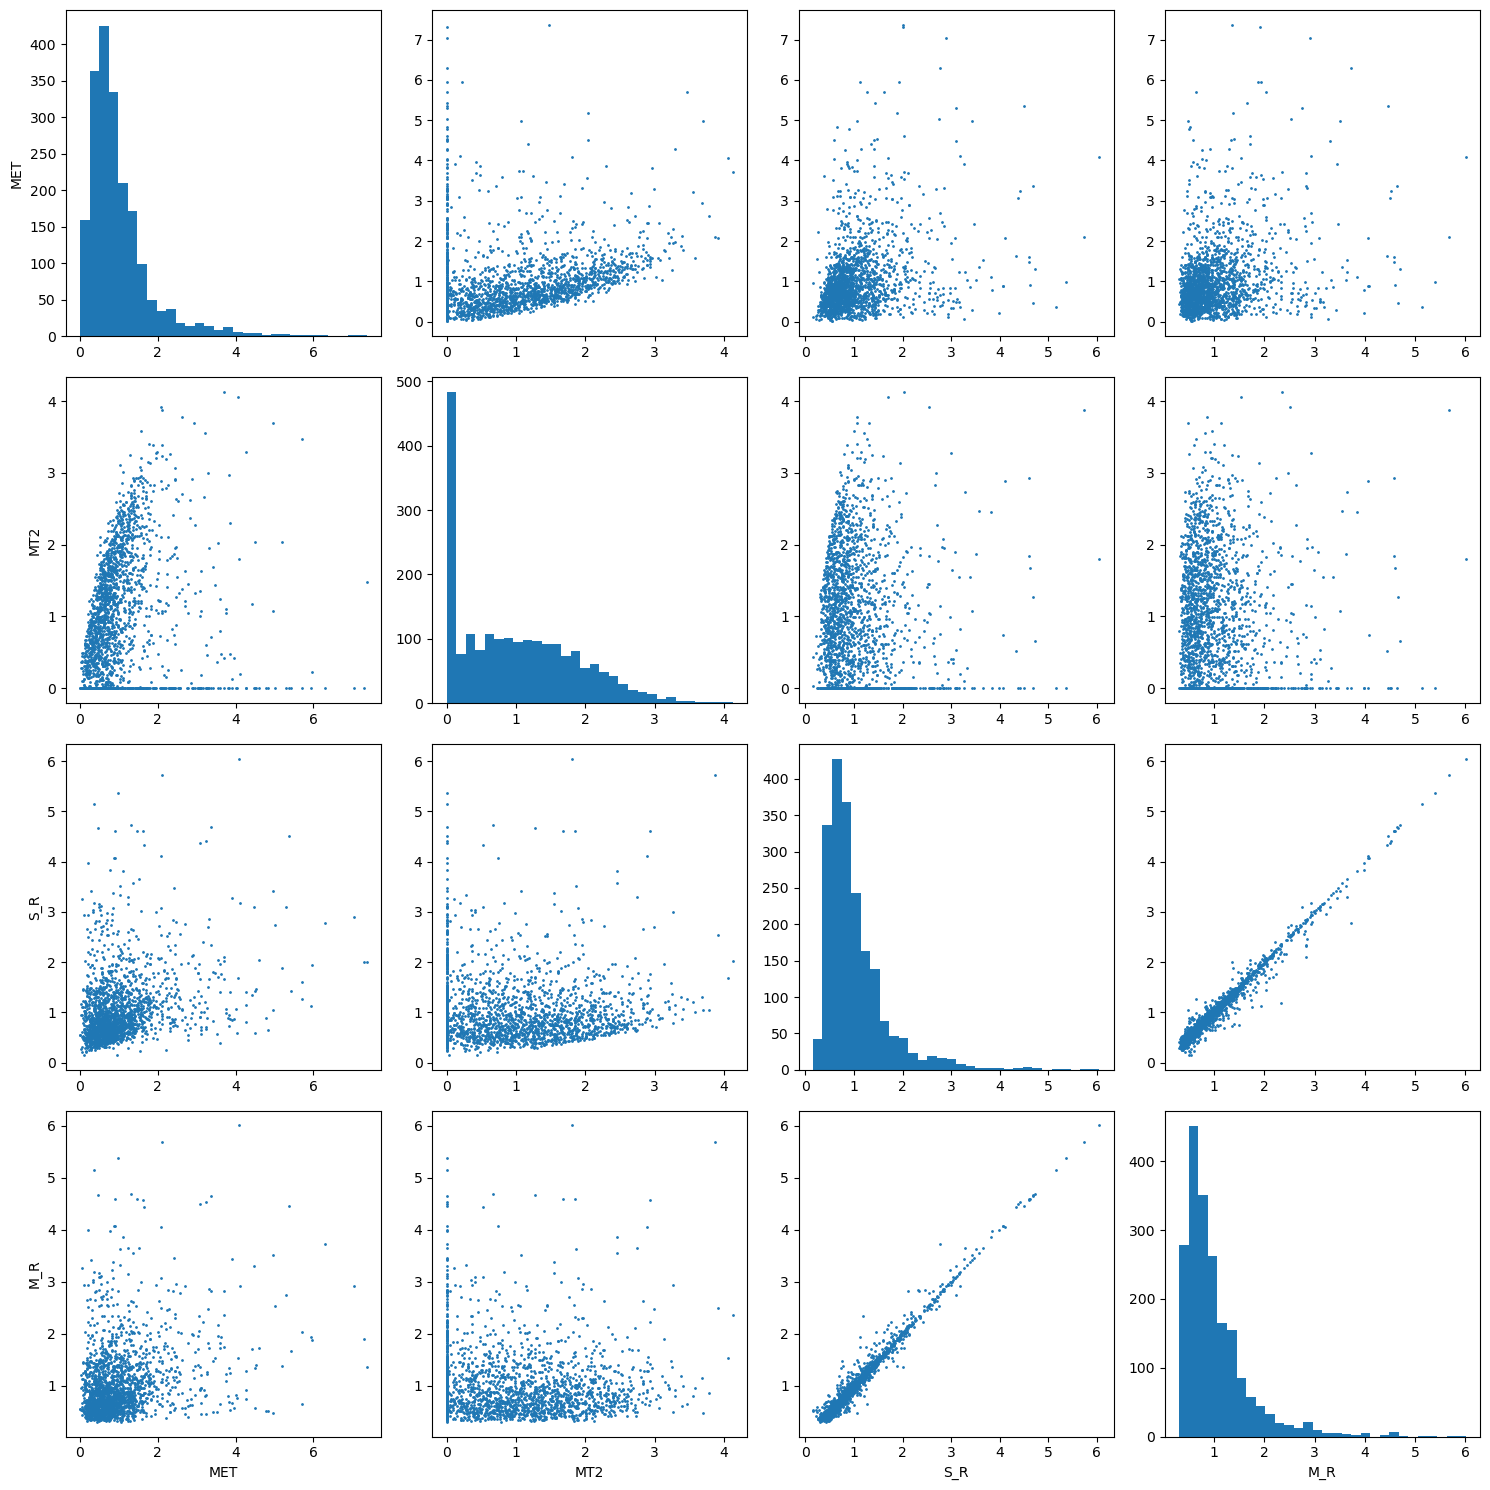

In [18]:
pair_plot(df, ["MET", "MT2", "S_R", "M_R"])

In [19]:
corr_matrix = df.corr()

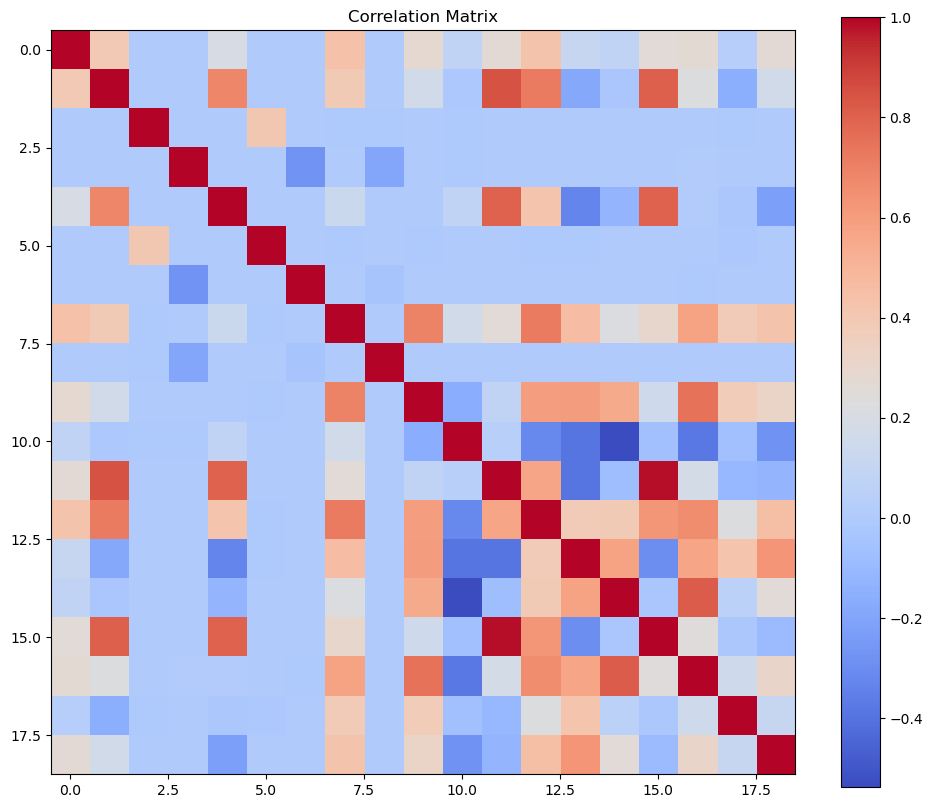

In [20]:
plt.figure(figsize=(12,10))

plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()

plt.title('Correlation Matrix')
plt.show()

In [21]:
cov_matrix = np.cov(df[VarNames[1:]].T)

print(cov_matrix)

[[ 4.67678634e-01 -1.66157135e-03 -1.61727488e-03  3.07141491e-01
  -1.27071270e-03 -1.51652950e-03  2.27478911e-01  5.95650543e-04
   9.95736942e-02 -6.83316993e-03  3.67086604e-01  2.85333907e-01
  -6.00356895e-02 -1.36717130e-02  3.45936274e-01  9.50833544e-02
  -4.68367454e-02  2.17123586e-02]
 [-1.66157135e-03  1.01174907e+00  1.90398226e-03  1.51958130e-03
   4.03986983e-01  4.05374834e-03 -5.26361801e-03 -5.82488677e-03
  -5.62706302e-04 -4.11641581e-03 -3.31896356e-04 -1.37512557e-03
  -3.72943750e-04  5.20102460e-04 -6.02267402e-04  2.64111875e-04
  -1.79500441e-03  1.57719919e-04]
 [-1.61727488e-03  1.90398226e-03  1.00051810e+00  3.57874701e-03
   2.72737652e-03 -2.69575147e-01  2.56070636e-03 -1.89861093e-01
   2.40421393e-03 -4.26174008e-03  1.61347372e-04  2.70188671e-03
   2.71750359e-03  7.00429753e-03  5.21700102e-04  6.08185827e-03
  -2.63448801e-04  6.49103611e-04]
 [ 3.07141491e-01  1.51958130e-03  3.57874701e-03  4.30244615e-01
   1.23187932e-04 -1.91023057e-03  7.

In [22]:
from sklearn.metrics import roc_curve, auc

In [23]:
def plot_roc(variable):

    y_true = df['signal']
    y_score = df[variable]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{variable} AUC={roc_auc:.3f}')

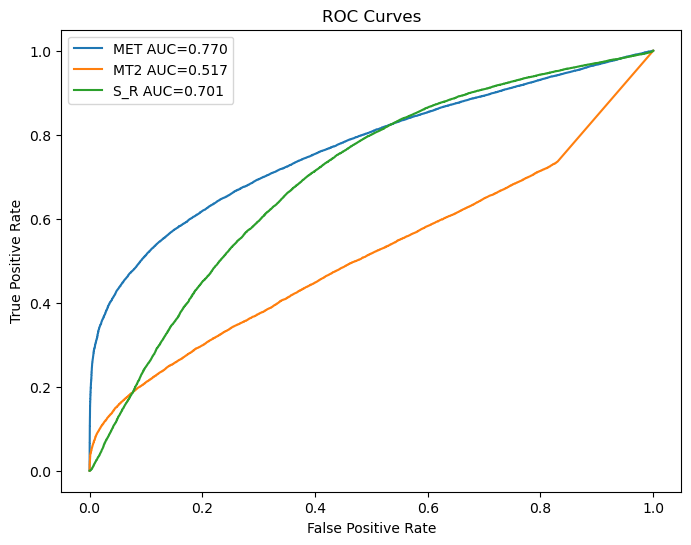

In [24]:
plt.figure(figsize=(8,6))

plot_roc('MET')
plot_roc('MT2')
plot_roc('S_R')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')

plt.legend()
plt.show()

In [31]:
#5.2
def plot_efficiency(variable):

    thresholds = np.linspace(df[variable].min(), df[variable].max(), 100)

    tpr_list = []
    fpr_list = []

    for cut in thresholds:

        signal_pass = df_sig[df_sig[variable] > cut]
        background_pass = df_bkg[df_bkg[variable] > cut]

        tpr = len(signal_pass) / len(df_sig)
        fpr = len(background_pass) / len(df_bkg)

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    plt.figure(figsize=(8,5))

    plt.plot(thresholds, tpr_list, label='TPR')
    plt.plot(thresholds, fpr_list, label='FPR')

    plt.xlabel('Cut Threshold')
    plt.ylabel('Efficiency')
    plt.title(f'TPR/FPR vs Threshold for {variable}')

    plt.legend()
    plt.show()

    return thresholds, tpr_list, fpr_list

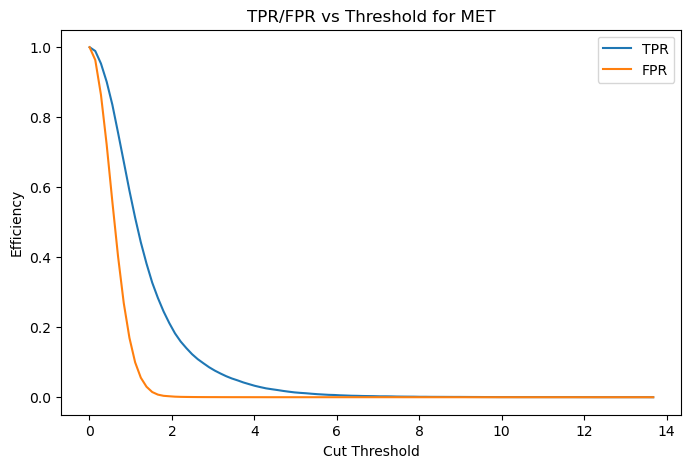

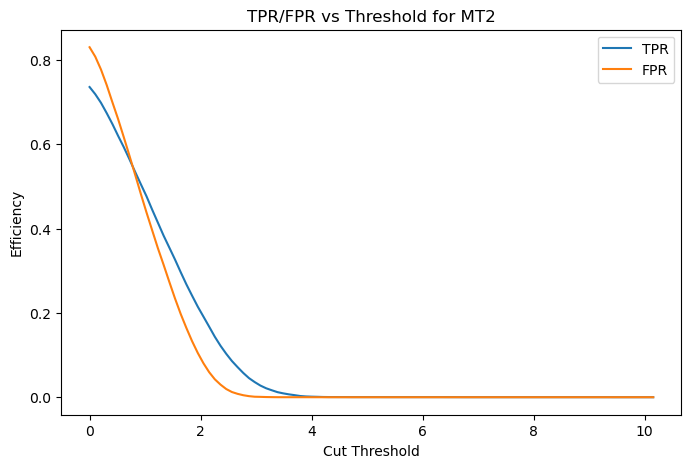

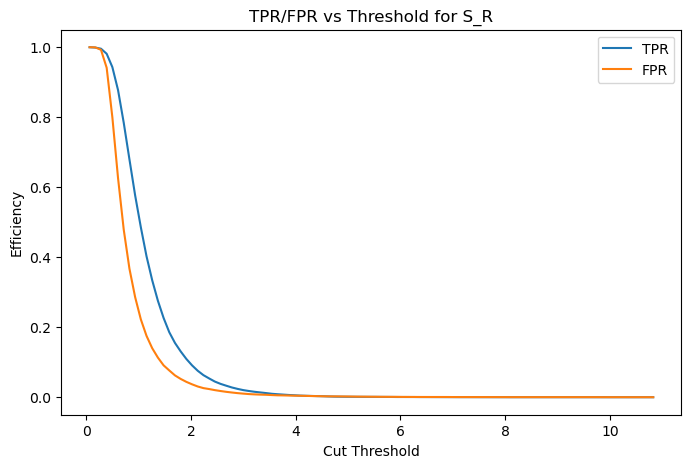

(array([ 0.06165959,  0.17041559,  0.27917159,  0.38792759,  0.49668359,
         0.60543959,  0.71419559,  0.82295159,  0.93170759,  1.04046359,
         1.14921959,  1.25797559,  1.36673159,  1.47548759,  1.58424359,
         1.69299959,  1.80175559,  1.91051159,  2.01926759,  2.12802359,
         2.23677959,  2.34553559,  2.45429159,  2.56304759,  2.67180359,
         2.78055959,  2.88931559,  2.99807159,  3.10682759,  3.21558359,
         3.32433959,  3.43309559,  3.54185159,  3.65060759,  3.75936359,
         3.86811959,  3.97687559,  4.08563159,  4.19438759,  4.30314359,
         4.41189959,  4.5206556 ,  4.6294116 ,  4.7381676 ,  4.8469236 ,
         4.9556796 ,  5.0644356 ,  5.1731916 ,  5.2819476 ,  5.3907036 ,
         5.4994596 ,  5.6082156 ,  5.7169716 ,  5.8257276 ,  5.9344836 ,
         6.0432396 ,  6.1519956 ,  6.2607516 ,  6.3695076 ,  6.4782636 ,
         6.5870196 ,  6.6957756 ,  6.8045316 ,  6.9132876 ,  7.0220436 ,
         7.1307996 ,  7.2395556 ,  7.3483116 ,  7.4

In [32]:
plot_efficiency('MET')
plot_efficiency('MT2')
plot_efficiency('S_R')

In [33]:
#5.3
def significance_plot(variable, NS, NB):

    thresholds = np.linspace(df[variable].min(), df[variable].max(), 100)

    significance = []

    for cut in thresholds:

        signal_pass = df_sig[df_sig[variable] > cut]
        background_pass = df_bkg[df_bkg[variable] > cut]

        eps_s = len(signal_pass) / len(df_sig)
        eps_b = len(background_pass) / len(df_bkg)

        NS_prime = eps_s * NS
        NB_prime = eps_b * NB

        sigma = NS_prime / np.sqrt(NS_prime + NB_prime + 1e-9)

        significance.append(sigma)

    plt.figure(figsize=(8,5))

    plt.plot(thresholds, significance)

    plt.xlabel('Threshold')
    plt.ylabel('Significance')
    plt.title(f'Significance vs Threshold for {variable}')

    plt.show()

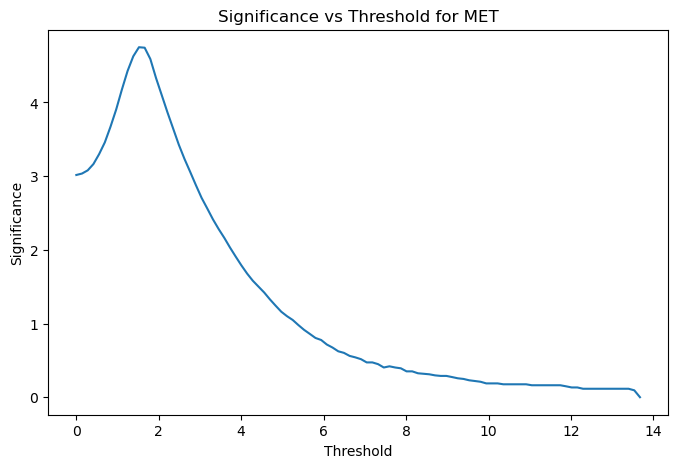

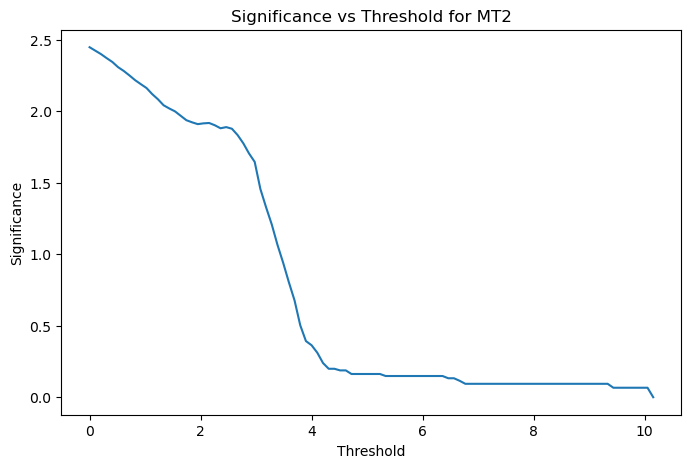

In [34]:
significance_plot('MET', 100, 1000)
significance_plot('MT2', 100, 1000)

In [36]:
#6.1
cuts = {
    'MET': 0.8,
    'MT2': 0.9,
    'S_R': 0.7
}
cut_df = df.copy()

for var, cut in cuts.items():
    cut_df = cut_df[cut_df[var] > cut]

print(cut_df.shape)

(11321, 19)


In [37]:
#6.2
flow = []

current_df = df.copy()

for var, cut in cuts.items():

    before = len(current_df)

    current_df = current_df[current_df[var] > cut]

    after = len(current_df)

    efficiency = after / before

    flow.append([var, cut, before, after, efficiency])

flow_df = pd.DataFrame(
    flow,
    columns=['Variable', 'Cut', 'Before', 'After', 'Efficiency']
)

flow_df

,Variable,Cut,Before,After,Efficiency
0,MET,0.8,50000,23836,0.476720
1,MT2,0.9,23836,15512,0.650780
2,S_R,0.7,15512,11321,0.729822


#6.3
MET and S_R show correlation. Applying cuts independently may overestimate significance because correlated variables remove similar events.

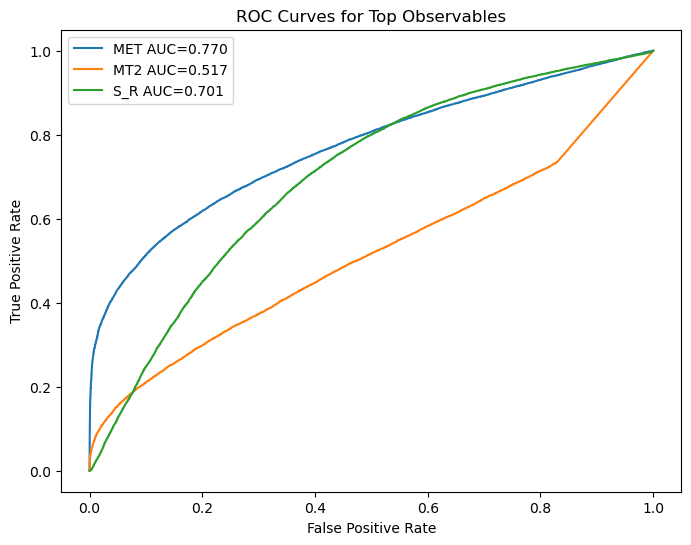

In [38]:
#7.1
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

variables = ['MET', 'MT2', 'S_R']

for var in variables:

    y_true = df['signal']
    y_score = df[var]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{var} AUC={roc_auc:.3f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Top Observables')

plt.legend()
plt.show()

In [39]:
#7.2
def compare_roc(data, variables):

    plt.figure(figsize=(8,6))

    for var in variables:

        y_true = data['signal']
        y_score = data[var]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'{var} AUC={roc_auc:.3f}')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Comparison')

    plt.legend()
    plt.show()

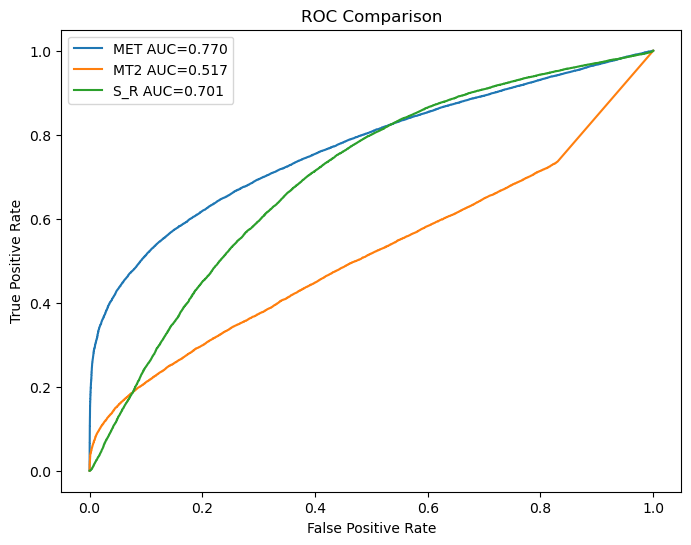

In [40]:
compare_roc(df, ['MET', 'MT2', 'S_R'])

In [41]:
#7.3
cut1 = df[df['MET'] > 0.8]
cut2 = cut1[cut1['MT2'] > 0.9]
cut3 = cut2[cut2['S_R'] > 0.7]

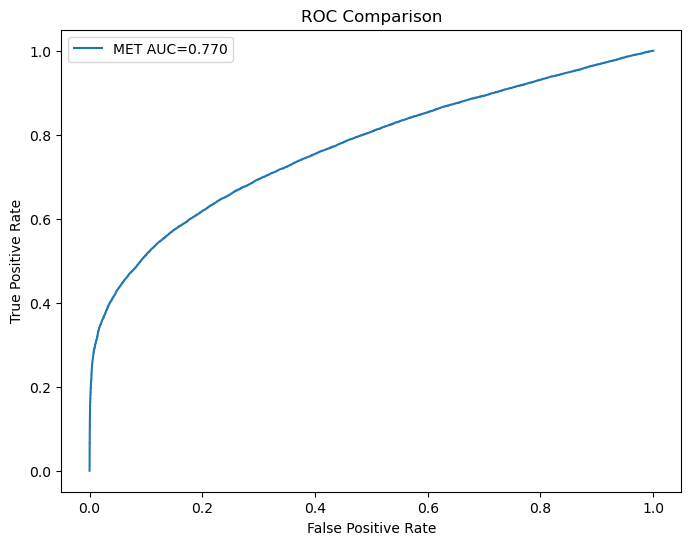

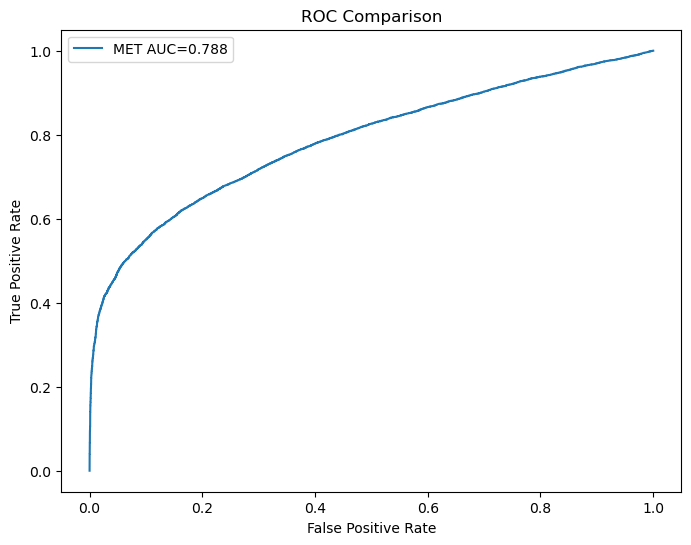

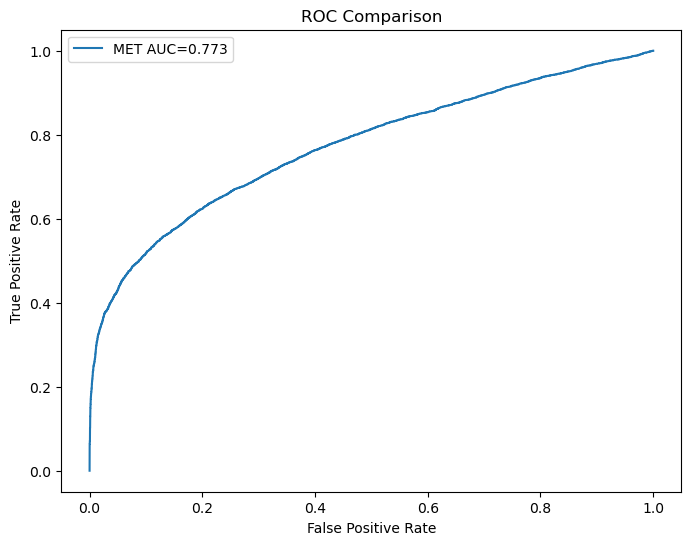

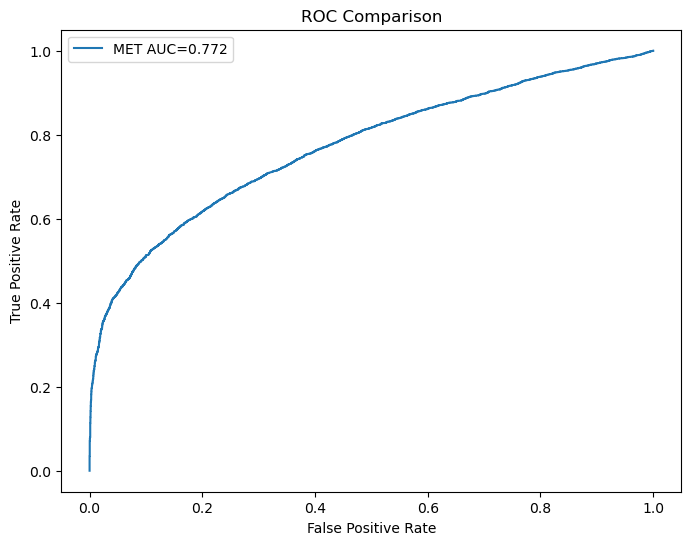

In [42]:
compare_roc(df, ['MET'])
compare_roc(cut1, ['MET'])
compare_roc(cut2, ['MET'])
compare_roc(cut3, ['MET'])

In [43]:
#7.4
alt_cut1 = df[df['S_R'] > 0.7]
alt_cut2 = alt_cut1[alt_cut1['MT2'] > 0.9]
alt_cut3 = alt_cut2[alt_cut2['MET'] > 0.8]

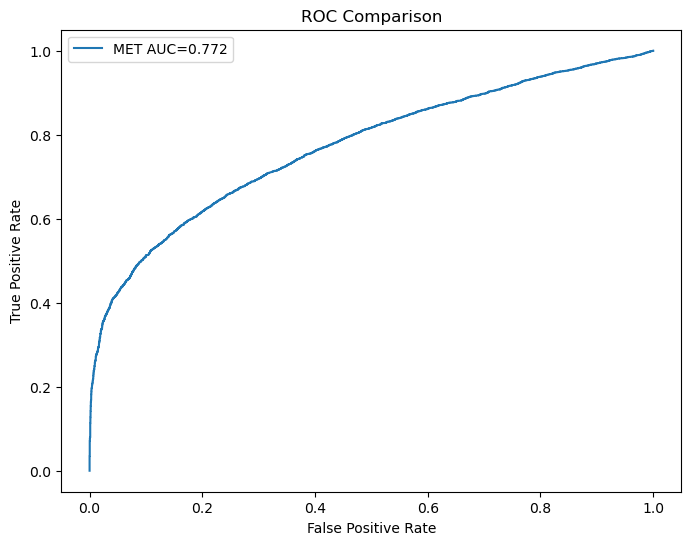

In [44]:
compare_roc(alt_cut3, ['MET'])

In [49]:
#8.1

X = df[VarNames[1:]].values
y = df['signal'].values

X_signal = X[y == 1]
X_background = X[y == 0]

m1 = np.mean(X_signal, axis=0)
m0 = np.mean(X_background, axis=0)

SB = np.outer((m1 - m0), (m1 - m0))

SW = np.cov(X_signal.T) + np.cov(X_background.T)

w = np.linalg.inv(SW).dot(m1 - m0)

F = X.dot(w)

print("LDA Complete")
print("Shape of F:", F.shape)

LDA Complete
Shape of F: (50000,)


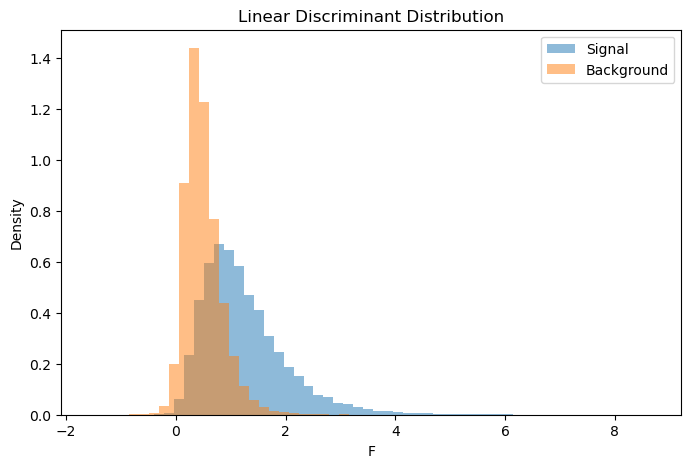

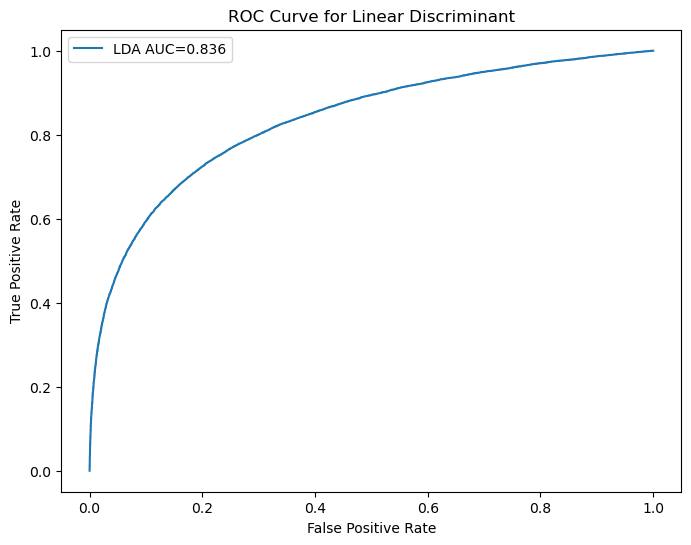

In [50]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,5))

plt.hist(F[y==1], bins=50, alpha=0.5, density=True, label='Signal')
plt.hist(F[y==0], bins=50, alpha=0.5, density=True, label='Background')

plt.xlabel('F')
plt.ylabel('Density')
plt.title('Linear Discriminant Distribution')

plt.legend()
plt.show()

fpr, tpr, _ = roc_curve(y, F)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'LDA AUC={roc_auc:.3f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Linear Discriminant')

plt.legend()
plt.show()

In [51]:
thresholds = np.linspace(F.min(), F.max(), 100)

best_sigma = 0
best_cut = 0

NS = 1000
NB = 10000

for cut in thresholds:

    signal_pass = F[y==1] > cut
    background_pass = F[y==0] > cut

    eps_s = np.sum(signal_pass) / np.sum(y==1)
    eps_b = np.sum(background_pass) / np.sum(y==0)

    NS_prime = eps_s * NS
    NB_prime = eps_b * NB

    sigma = NS_prime / np.sqrt(NS_prime + NB_prime + 1e-9)

    if sigma > best_sigma:
        best_sigma = sigma
        best_cut = cut

print("Best Significance:", best_sigma)
print("Best Threshold:", best_cut)

Best Significance: 15.157764989825015
Best Threshold: 1.1238364969067343
